In [36]:
import pandas as pd
import numpy as np

df = pd.read_excel('./analysis-data/lines_TopicDistribution.xlsx')

In [37]:
local_freq = df[df.source=='Local']['percentage'].tolist()
nonlocal_freq = df[df.source=='Non-local']['percentage'].tolist()

## Gini 

In [40]:
def gini(x):
    x = np.array(x, dtype=float)
    if np.any(x < 0):
        raise ValueError("Values cannot be negative")
    if np.sum(x) == 0:
        return 0.0
    
    x = np.sort(x)  # 从小到大
    n = len(x)
    cumindex = np.arange(1, n + 1)
    
    return (2 * np.sum(cumindex * x)) / (n * np.sum(x)) - (n + 1) / n

In [41]:
gini_local = gini(local_freq)
gini_nonlocal = gini(nonlocal_freq)

print("Local Gini:", round(gini_local, 4))
print("Non-local Gini:", round(gini_nonlocal, 4))

Local Gini: 0.4305
Non-local Gini: 0.516


In [42]:
import matplotlib.pyplot as plt

In [43]:
def lorenz_curve(x):
    # 返回洛伦兹曲线坐标
    x = np.array(x, dtype=float)
    x = np.sort(x)  # 从小到大
    cumx = np.cumsum(x)
    cumx = np.insert(cumx, 0, 0)  # 开头补0
    cumx = cumx / cumx[-1]        # 归一化
    
    n = len(x)
    cum_pop = np.arange(0, n + 1) / n
    
    return cum_pop, cumx

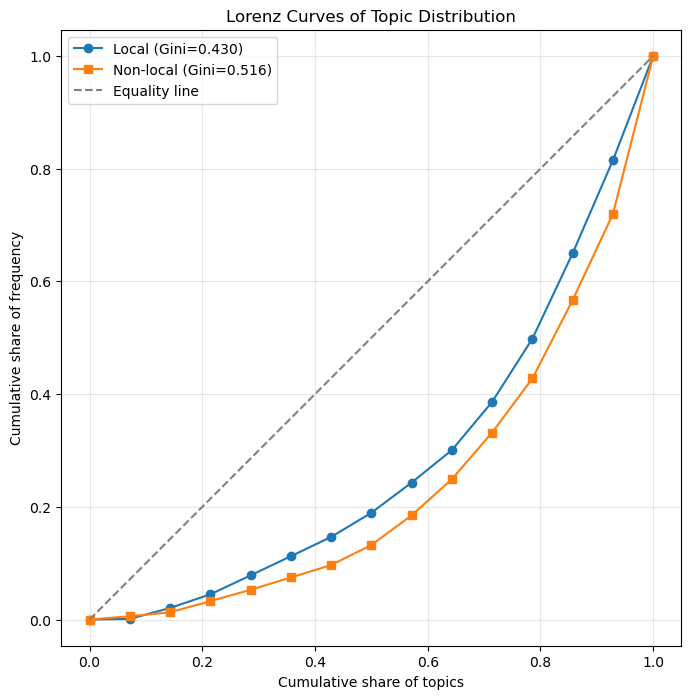

In [44]:
x_local, y_local = lorenz_curve(local_freq)
x_nonlocal, y_nonlocal = lorenz_curve(nonlocal_freq)

# 画图
plt.figure(figsize=(8, 8))
plt.plot(x_local, y_local, marker='o', label=f'Local (Gini={gini_local:.3f})')
plt.plot(x_nonlocal, y_nonlocal, marker='s', label=f'Non-local (Gini={gini_nonlocal:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Equality line')

plt.title('Lorenz Curves of Topic Distribution')
plt.xlabel('Cumulative share of topics')
plt.ylabel('Cumulative share of frequency')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

In [45]:
lorenz_df = pd.DataFrame({
    'cum_topic_share': x_local,
    'local_lorenz': y_local,
    'nonlocal_lorenz': y_nonlocal,
    'equality_line': x_local
}).round(2)

lorenz_df.to_excel('./analysis-data/topic_lorenz_curves.xlsx', index=False)

In [46]:
def output(freqs):
    freqs_sorted = np.sort(freqs)
    n = len(freqs)
    total = np.sum(freqs)
    
    # 基尼系数
    p = np.arange(1, n + 1) / n
    cum_income = np.cumsum(freqs_sorted) / total
    gini = 1 - np.sum((p - np.insert(p, 0, 0)[:-1]) * (cum_income + np.insert(cum_income, 0, 0)[:-1]))
    
    # 香农指数
    probs = freqs / total
    shannon = -np.sum(probs * np.log(probs))
    shannon_norm = shannon / np.log(n)
    
    print(f"基尼系数: {gini:.4f}")

In [47]:
output(local_freq)

基尼系数: 0.4305


In [48]:
output(nonlocal_freq)

基尼系数: 0.5160
